In [1]:
import numpy as np # Math
import pandas as pd # Data tables
import matplotlib.pyplot as plt # Plots
import sklearn # Classic ML

Best Parameters: {'model__n_neighbors': 9}
Best Score: 0.69492


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,split93_test_score,split94_test_score,split95_test_score,split96_test_score,split97_test_score,split98_test_score,split99_test_score,mean_test_score,std_test_score,rank_test_score
0,0.039510,0.024326,0.140004,0.020614,3,{'model__n_neighbors': 3},0.728525,0.647571,0.662194,0.679041,...,0.653877,0.634713,0.680367,0.665802,0.668695,0.648265,0.695431,0.663289,0.023184,10
1,0.028627,0.002882,0.142894,0.015606,5,{'model__n_neighbors': 5},0.752451,0.663251,0.685684,0.698064,...,0.677462,0.669655,0.697512,0.686597,0.681299,0.686879,0.712755,0.686639,0.019739,8
2,0.028131,0.002071,0.156459,0.016982,7,{'model__n_neighbors': 7},0.756710,0.669001,0.696433,0.699888,...,0.680719,0.680784,0.697330,0.691180,0.686505,0.696754,0.714210,0.692909,0.019254,5
3,0.028900,0.003410,0.164179,0.018451,9,{'model__n_neighbors': 9},0.757205,0.668834,0.688181,0.705733,...,0.679090,0.681742,0.700045,0.693260,0.684049,0.699328,0.718181,0.694917,0.018956,1
4,0.028052,0.002297,0.176554,0.018754,11,{'model__n_neighbors': 11},0.755136,0.668032,0.688661,0.704998,...,0.682278,0.681986,0.704229,0.693074,0.685372,0.700344,0.716675,0.694660,0.018048,2
5,0.028716,0.003466,0.186862,0.019623,13,{'model__n_neighbors': 13},0.754057,0.669510,0.688065,0.703864,...,0.683859,0.682702,0.704763,0.689137,0.684929,0.696315,0.712908,0.694123,0.017659,3
6,0.028618,0.003752,0.195473,0.027380,15,{'model__n_neighbors': 15},0.750416,0.667064,0.685795,0.704298,...,0.686024,0.683211,0.708474,0.688575,0.684175,0.693638,0.712421,0.693818,0.017233,4
7,0.030846,0.014446,0.243947,0.039548,17,{'model__n_neighbors': 17},0.749122,0.668968,0.685015,0.706218,...,0.685424,0.681878,0.705974,0.689785,0.683524,0.692726,0.710776,0.692816,0.016955,6
8,0.040116,0.016723,0.258705,0.057034,19,{'model__n_neighbors': 19},0.747403,0.665121,0.684291,0.704007,...,0.685992,0.683590,0.705313,0.687994,0.681654,0.691038,0.710595,0.691431,0.017031,7
9,0.045747,0.021914,0.370025,0.090232,60,{'model__n_neighbors': 60},0.719363,0.646963,0.664063,0.677096,...,0.671731,0.667337,0.676732,0.660262,0.657388,0.668065,0.686567,0.669250,0.016605,9


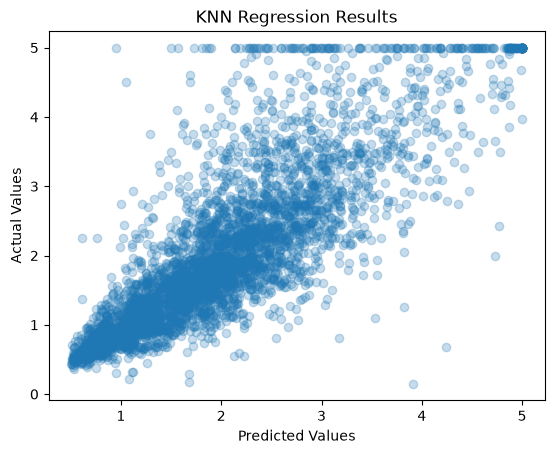

R^2 Score: 0.67596


In [2]:
# Scikit-learn: KNN Regression

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RepeatedKFold, train_test_split

from sklearn.neighbors import KNeighborsRegressor

kn_pipe = Pipeline([
    ('scaler', StandardScaler()), # Standardize the features
    ('model', KNeighborsRegressor()) # KNN Regressor
])
x, y = fetch_california_housing(return_X_y=True) # get data features and target values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) # Split the data into training and testing sets

grid_search = GridSearchCV(estimator=kn_pipe, #tune the hyperparameters of the KNN model using grid search
             param_grid={'model__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 60]},
             cv=RepeatedKFold(n_splits=10, n_repeats=10), # 10-fold cross-validation, 10 different random variations of the data
             n_jobs=-1) # Use all available cores for parallel processing

KN_model = grid_search.fit(x_train, y_train) # Fit the model to the training data

print(f"Best Parameters: {KN_model.best_params_}") # Print the best parameters found by the grid search
print(f"Best Score: {KN_model.best_score_:.5f}") # Print the best score found by the grid search

results = pd.DataFrame(grid_search.cv_results_) # Get the cross-validation results
display(results) # Display the cross-validation results

plt.scatter(KN_model.predict(x_test), y_test, alpha=0.25)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('KNN Regression Results')
plt.show()

accuracy = KN_model.score(x_test, y_test) # R^2 score of the model
print(f"R^2 Score: {accuracy:.5f}")
